Notebook 7 — Forecasting & Predictive Analytics


Objective
The purpose of this notebook is to develop advanced forecasting and predictive analytics solutions using the Global Superstore dataset. The analysis leverages machine learning, time-series modeling, and statistical forecasting techniques to identify future business trends, improve decision-making, and support strategic planning initiatives.

This notebook focuses on:

* Sales forecasting
* Profit forecasting
* Time-series analysis
* Predictive analytics
* Demand forecasting
* Business trend analysis
* Machine learning model development
* Forecasting model evaluation

Business Questions

This analysis seeks to answer the following key business questions:

1. How are sales expected to perform in future periods?
2. What profit trends can be anticipated based on historical performance?
3. Which machine learning models provide the most accurate forecasts?
4. What seasonal patterns influence sales and profitability?
5. How can forecasting improve inventory, budgeting, and operational planning?
6. Which factors have the greatest impact on future business performance?

Analytical Approach

The notebook applies a structured forecasting framework consisting of:

* Data preparation and feature engineering
* Time-series trend analysis
* Seasonal pattern identification
* Forecasting model development
* Machine learning model comparison
* Classification modeling with SMOTE balancing
* Model performance evaluation
* Executive-level business interpretation

Machine Learning Models

The following predictive models are evaluated and compared:

Forecasting Models

* Linear Regression
* Random Forest Regressor
* Gradient Boosting Regressor
* XGBoost Regressor

Classification Models

* Logistic Regression
* Random Forest Classifier
* Gradient Boosting Classifier
* XGBoost Classifier
* SMOTE-enhanced classification models

Forecasting Evaluation Metrics

Model performance is evaluated using:

* Mean Absolute Error (MAE)
* Root Mean Squared Error (RMSE)
* Mean Absolute Percentage Error (MAPE)
* R-Squared (R²)
* Accuracy
* Precision
* Recall
* F1 Score
* ROC-AUC

Business Value

The analytical outputs generated in this notebook support:

* Strategic planning
* Executive forecasting
* Revenue projection
* Demand planning
* Inventory optimization
* Budget forecasting
* Profitability improvement
* Risk management
* Resource allocation
* Business intelligence reporting

Expected Outcomes

Upon completion, this notebook will provide:

* Reliable sales forecasts
* Profit prediction models
* Business trend forecasts
* Machine learning performance comparisons
* Key profitability drivers
* Executive-level insights and recommendations
* Data-driven decision support for future business growth


In [1]:
import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

import os

from imblearn.over_sampling  import SMOTE
from xgboost import XGBRegressor, XGBClassifier
from sklearn.linear_model    import LinearRegression, LogisticRegression
from sklearn.ensemble        import (RandomForestRegressor, GradientBoostingRegressor, RandomForestClassifier, GradientBoostingClassifier)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing   import LabelEncoder
from sklearn.metrics         import (mean_absolute_error, mean_squared_error, r2_score,accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve)



In [2]:
orders = pd.read_csv("C:/Users/jsero/OneDrive/Desktop/Analyst Portfolio/Global Sales Enterprise/processed_orders.csv")
orders["order_date"] = pd.to_datetime(orders["order_date"])
orders["ship_date"] = pd.to_datetime(orders["ship_date"])



__________________________

Time Series Analysis

In [3]:
monthly_sales = (orders.groupby(orders["order_date"].dt.to_period("M"))["sales"].sum().reset_index())
monthly_sales["order_date"] = (monthly_sales["order_date"].dt.to_timestamp())

monthly_sales['month'] = monthly_sales["order_date"].dt.month
monthly_sales['quarter'] = monthly_sales["order_date"].dt.quarter
monthly_sales['year'] = monthly_sales["order_date"].dt.year

#Create Lags
monthly_sales["lag_1"] = monthly_sales["sales"].shift(1)
monthly_sales["lag_3"] = monthly_sales["sales"].shift(3)
monthly_sales["lag_6"] = monthly_sales["sales"].shift(6)

monthly_sales.head()

,order_date,sales,month,quarter,year,lag_1,lag_3,lag_6
0,2011-01-01,89531.74926,1,1,2011,NaN,NaN,NaN
1,2011-02-01,86376.31794,2,1,2011,89531.74926,NaN,NaN
2,2011-03-01,139946.69256,3,1,2011,86376.31794,NaN,NaN
3,2011-04-01,112221.03750,4,2,2011,139946.69256,89531.74926,NaN
4,2011-05-01,138074.12910,5,2,2011,112221.03750,86376.31794,NaN


___________________________________________

Monthly Sales Forecasting Dataset

In [4]:
monthly_sales["time_index"] = np.arange(len(monthly_sales))
monthly_sales.head()


,order_date,sales,month,quarter,year,lag_1,lag_3,lag_6,time_index
0,2011-01-01,89531.74926,1,1,2011,NaN,NaN,NaN,0
1,2011-02-01,86376.31794,2,1,2011,89531.74926,NaN,NaN,1
2,2011-03-01,139946.69256,3,1,2011,86376.31794,NaN,NaN,2
3,2011-04-01,112221.03750,4,2,2011,139946.69256,89531.74926,NaN,3
4,2011-05-01,138074.12910,5,2,2011,112221.03750,86376.31794,NaN,4


1. Monthly Sales Trend

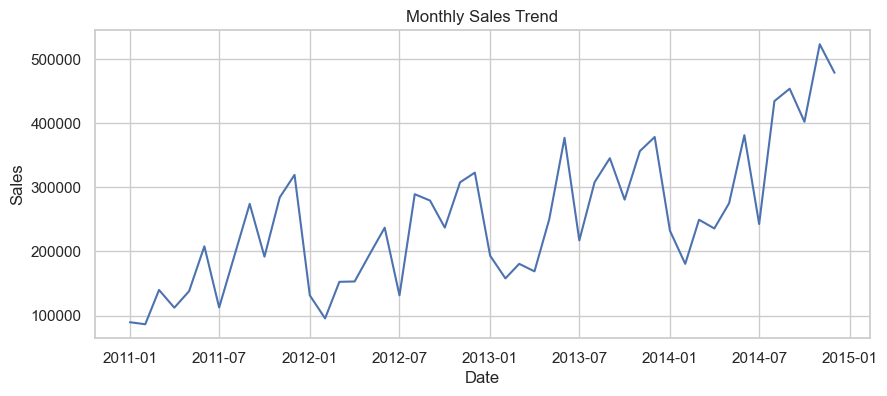

In [5]:
plt.figure(figsize=(10,4))
plt.plot(monthly_sales["order_date"],monthly_sales["sales"])
plt.title("Monthly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

2. Moving Average Trend

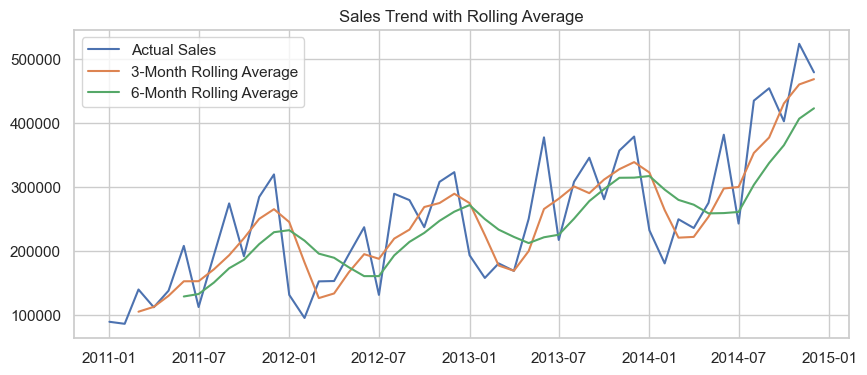

In [6]:
monthly_sales["rolling_avg_3"] = ( monthly_sales["sales"].rolling(window=3).mean())
monthly_sales["rolling_avg_6"] = (monthly_sales["sales"].rolling(window=6).mean())

plt.figure(figsize=(10,4))
plt.plot(monthly_sales["order_date"],monthly_sales["sales"],label="Actual Sales")
plt.plot(monthly_sales["order_date"],monthly_sales["rolling_avg_3"], label="3-Month Rolling Average")
plt.plot(monthly_sales["order_date"],monthly_sales["rolling_avg_6"], label="6-Month Rolling Average")
plt.legend()
plt.title("Sales Trend with Rolling Average")
plt.show()

Insights

The macro-level trend evaluation in this operational time-series series, utilizes a multi-line graph to analyze the company's long-term sales velocity. The visualization overlays Actual Sales data with a 3-Month Rolling Average and a 6-Month Rolling Average to smooth out short-term fluctuations and capture underlying growth vectors over a four-year horizon.

Longitudinal Growth and Cyclical Volatility

The chart reveals a powerful, long-term upward trajectory characterized by high month-to-month volatility and prominent seasonal demand shifts:

The Foundational Baseline (2011):The business began its tracked timeline in early 2011 with a monthly revenue floor sitting just under 100,000. Early momentum pushed actual monthly sales to an initial peak slightly above 200,000 mid-year before encountering sharp cyclical dips.


The Mid-Timeline Acceleration (2012–2013): Throughout 2012 and 2013, the core revenue baseline steadily scaled upward. Peak periods progressively notched higher milestones, culminating in a major seasonal breakout in late 2013 where actual monthly sales surged past the 370,000 threshold.


The Historic Breakout (2014): The macro expansion strategy reached its apex in late 2014. After navigating a standard first-quarter contraction, sales volumes surged dramatically during the back half of the year, exploding to an absolute historic monthly record that breached 520,000 before tapering off into the close of the year.


Rolling Smoothing Diagnostics

By incorporating rolling calculations, I effectively filters out high-frequency transactional noise to track structural demand shifts:

The 3-Month Rolling Average: Tracking closely behind the raw monthly figures, the orange line captures mid-tier seasonal fluctuations. It highlights the swift, multi-month build-ups leading into annual peak quarters, as well as the steepness of the post-holiday sales drops.


The 6-Month Rolling Average:The green line acts as the ultimate macro baseline. By smoothing out sudden single-month spikes and valleys, it presents an uninterrupted visual proof of the organization's compounding growth. The 6-month metric advances from a starting baseline near 130,000 in mid-2011 to a robust terminal position exceeding 420,000 by late 2014.

Macro-Strategic Takeaway

When evaluated alongside the previously reviewed quarterly and monthly profit datasets, this time-series visualization provides critical strategic confirmation for corporate planning. It proves that the business possesses exceptional top-line sales momentum that is scaling predictably year-over-year.

However, the deep, recurring monthly valleys—particularly the routine plunges observed at the start of each fiscal year—signal that inventory management and staffing structures must remain highly flexible. Because the smoothed 6-month average establishes a dependable, rising baseline floor, leadership can confidently plan macro infrastructure investments around this long-term growth path while using the rolling averages to optimize supply-chain lead times and safety stock buffers against severe seasonal peaks and troughs.

-----------------------------------

Moving Average Forecasting

In [7]:
monthly_sales["moving_avg_forecast"] = (monthly_sales["sales"].rolling(window=3).mean().shift(1))
monthly_sales.head(10)

,order_date,sales,month,quarter,year,lag_1,lag_3,lag_6,time_index,rolling_avg_3,rolling_avg_6,moving_avg_forecast
0,2011-01-01,89531.74926,1,1,2011,NaN,NaN,NaN,0,NaN,NaN,NaN
1,2011-02-01,86376.31794,2,1,2011,89531.74926,NaN,NaN,1,NaN,NaN,NaN
2,2011-03-01,139946.69256,3,1,2011,86376.31794,NaN,NaN,2,105284.91992,NaN,NaN
3,2011-04-01,112221.03750,4,2,2011,139946.69256,89531.74926,NaN,3,112848.01600,NaN,105284.91992
4,2011-05-01,138074.12910,5,2,2011,112221.03750,86376.31794,NaN,4,130080.61972,NaN,112848.01600
5,2011-06-01,208063.09458,6,2,2011,138074.12910,139946.69256,NaN,5,152786.08706,129035.50349,130080.61972
6,2011-07-01,112576.17612,7,3,2011,208063.09458,112221.03750,89531.74926,6,152904.46660,132876.24130,152786.08706
7,2011-08-01,193523.08290,8,3,2011,112576.17612,138074.12910,86376.31794,7,171387.45120,150734.03546,152904.46660
8,2011-09-01,274393.69614,9,3,2011,193523.08290,208063.09458,139946.69256,8,193497.65172,173141.86939,171387.45120
9,2011-10-01,191935.78854,10,4,2011,274393.69614,112576.17612,112221.03750,9,219950.85586,186427.66123,193497.65172


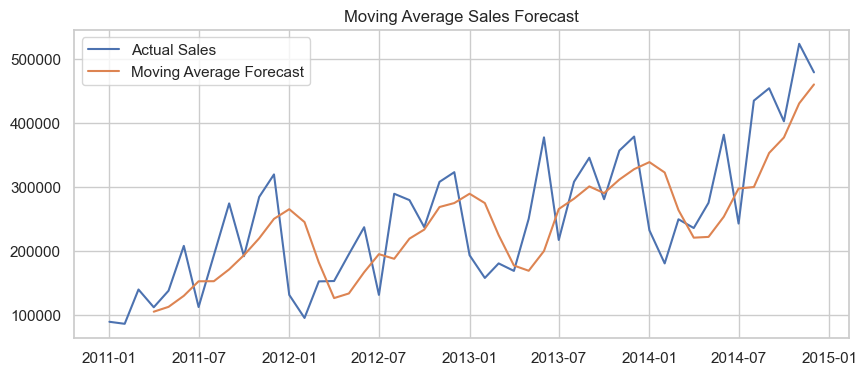

In [9]:
plt.figure(figsize=(10,4))

plt.plot( monthly_sales["order_date"],monthly_sales["sales"],label="Actual Sales")
plt.plot(monthly_sales["order_date"],monthly_sales["moving_avg_forecast"],label="Moving Average Forecast")
plt.legend()
plt.title("Moving Average Sales Forecast")
plt.show()

____________________________________________

Machine Learning Section

This section applies a full machine learning pipeline directly to the order-level dataset. No time-series constructs (lags, rolling averages) are used — models learn from the raw order attributes that exist at the point of transaction.

Pipeline:
1. Data Preparation — encoding, target definition, train/test split
2. Regression — predict `sales` and `profit` across all models in a loop
3. Classification — predict high-profit orders across all models in a loop
4. Model comparison tables and visualisations
5. Feature importance analysis
6. Business risk analysis
7. Export

-----
 1. Data Preparation

The order-level dataset is prepared for machine learning:
- Date columns are dropped (not useful as raw ML features)
- ID columns are dropped (no predictive signal)
- All categorical columns are label-encoded
- A binary high_profit target is created for classification (above-median profit = 1)
- A single 80/20 stratified train/test split is used consistently across all models

In [35]:
print(orders.columns)

Index(['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode',
       'customer_id', 'customer_name', 'segment', 'city', 'state', 'country',
       'market', 'region', 'product_id', 'category', 'sub_category',
       'product_name', 'sales', 'quantity', 'discount', 'profit',
       'shipping_cost', 'order_priority', 'order_year', 'order_month',
       'order_day', 'order_quarter', 'order_weekday', 'is_weekend',
       'shipping_days', 'shipping_speed', 'profit_margin',
       'high_discount_flag', 'loss_order_flag', 'total_orders',
       'customer_lifetime_value', 'avg_order_value', 'product_total_sales',
       'product_total_profit', 'regional_total_sales', 'high_sales_anomaly',
       'extreme_discount_flag', 'negative_profit_flag'],
      dtype='object')


In [58]:
ml_df = orders.copy()


drop_cols = ["order_id", "customer_id", "order_date", "ship_date",'profit_margin',
       'high_discount_flag', 'loss_order_flag', 'total_orders',
       'customer_lifetime_value', 'avg_order_value', 'product_total_sales',
       'product_total_profit', 'regional_total_sales', 'high_sales_anomaly',
       'extreme_discount_flag', 'negative_profit_flag']
ml_df.drop(columns=[c for c in drop_cols if c in ml_df.columns], inplace=True)


for col in ml_df.select_dtypes(include="object").columns:
    ml_df[col] = LabelEncoder().fit_transform(ml_df[col].astype(str))


SALES_TARGET  = "sales"
PROFIT_TARGET = "profit"


ml_df["high_profit"] = (ml_df["profit"] > ml_df["profit"].median()).astype(int)
CLF_TARGET = "high_profit"

print(f"Dataset shape      : {ml_df.shape}")
print(f"Features available : {ml_df.shape[1] - 1}")
print(f"High-profit rate   : {ml_df['high_profit'].mean():.1%}")
ml_df.head()

Dataset shape      : (48690, 28)
Features available : 27
High-profit rate   : 50.0%


,row_id,ship_mode,customer_name,segment,city,state,country,market,region,product_id,...,order_priority,order_year,order_month,order_day,order_quarter,order_weekday,is_weekend,shipping_days,shipping_speed,high_profit
0,26341,2,413,1,3477,697,6,0,9,902,...,0,2013,2,5,1,5,0,2,0,0
1,25330,0,181,0,492,815,6,0,9,10073,...,3,2013,10,17,4,4,0,1,0,1
2,13524,0,424,2,372,145,47,4,3,10062,...,3,2013,1,28,1,1,0,2,0,0
3,47221,1,632,0,849,269,110,1,0,10165,...,0,2013,11,5,4,5,0,1,0,1
4,22732,2,376,1,3071,697,6,0,9,9548,...,0,2013,6,28,2,0,0,3,1,1


---
 2. Model Registries

All regression and classification models are registered in dictionaries.
The evaluation loops below iterate over every model automatically — adding or
removing a model requires only a single line change here.

In [59]:
REGRESSOR_REGISTRY = {
    "Linear Regression" : LinearRegression(),
    "Random Forest"     : RandomForestRegressor(n_estimators=300, max_depth=10, random_state=42),
    "Gradient Boosting" : GradientBoostingRegressor(n_estimators=300, learning_rate=0.05,max_depth=4, random_state=42),
    "XGBoost" : XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=4,verbosity=0, random_state=42)
}


CLASSIFIER_REGISTRY = {
    "Logistic Regression" : LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest"       : RandomForestClassifier(n_estimators=300, random_state=42),
    "Gradient Boosting"   : GradientBoostingClassifier(n_estimators=300, random_state=42),
    "XGBoost" : XGBClassifier(n_estimators=300, use_label_encoder=False,eval_metric="logloss", verbosity=0, random_state=42)
}


---
3. Regression — Sales Prediction

All regression models are trained and evaluated in a single loop on theorder-level dataset with sales as the target. An 80/20 random split is used.

In [60]:
def run_regression_loop(df, target_col, registry, test_size=0.2, random_state=42):
    """Train and evaluate all regressors. Returns results_df, predictions dict, fitted dict."""
    feature_cols = [c for c in df.columns
                    if c not in [target_col, "high_profit", SALES_TARGET, PROFIT_TARGET]
                    or c == target_col]
    # Use all columns except other targets
    exclude = {"high_profit", SALES_TARGET, PROFIT_TARGET} - {target_col}
    X = df.drop(columns=list(exclude))
    X = X.drop(columns=[target_col])
    y = df[target_col]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state)

    results, predictions, fitted = [], {}, {}

    for name, mdl in registry.items():
        mdl.fit(X_train, y_train)
        y_pred = mdl.predict(X_test)

        mae  = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2   = r2_score(y_test, y_pred)
        mape = np.mean(np.abs((y_test - y_pred) / y_test.replace(0, np.nan))) * 100

        results.append({"Model": name,"MAE": round(mae, 2),"RMSE": round(rmse, 2),"R²": round(r2, 4),"MAPE (%)": round(mape, 2)})
        predictions[name] = {"y_test": y_test, "y_pred": y_pred}
        fitted[name] = mdl

    results_df = (pd.DataFrame(results).sort_values("R²", ascending=False).reset_index(drop=True))
    return results_df, predictions, fitted, X_test, y_test

sales_results_df, sales_preds, sales_fitted, X_test_s, y_test_s = run_regression_loop(ml_df, SALES_TARGET, REGRESSOR_REGISTRY)


print("  SALES REGRESSION — MODEL COMPARISON")
sales_results_df

  SALES REGRESSION — MODEL COMPARISON


,Model,MAE,RMSE,R²,MAPE (%)
0,Gradient Boosting,66.80,186.92,0.8149,46.55
1,XGBoost,68.13,190.27,0.8082,45.99
2,Random Forest,71.09,194.54,0.7995,45.10
3,Linear Regression,118.36,238.54,0.6986,226.28


---
4. Regression — Profit Prediction


In [61]:


PROFIT_REGISTRY = {
    "Linear Regression" : LinearRegression(),
    "Random Forest"     : RandomForestRegressor(n_estimators=300, max_depth=10, random_state=42),
    "Gradient Boosting" : GradientBoostingRegressor(n_estimators=300, learning_rate=0.05,max_depth=4, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=4,verbosity=0, random_state=42)
}

profit_results_df, profit_preds, profit_fitted, X_test_p, y_test_p = run_regression_loop(ml_df, PROFIT_TARGET, PROFIT_REGISTRY)

print("  PROFIT REGRESSION — MODEL COMPARISON")
profit_results_df

  PROFIT REGRESSION — MODEL COMPARISON


,Model,MAE,RMSE,R²,MAPE (%)
0,Gradient Boosting,39.24,95.84,0.5567,992.87
1,XGBoost,39.56,96.69,0.5489,931.55
2,Random Forest,39.59,100.28,0.5148,1002.06
3,Linear Regression,60.20,125.39,0.2413,2102.42


---
Model Comparison Visualisations

1. Sales Regression — Metric Comparison

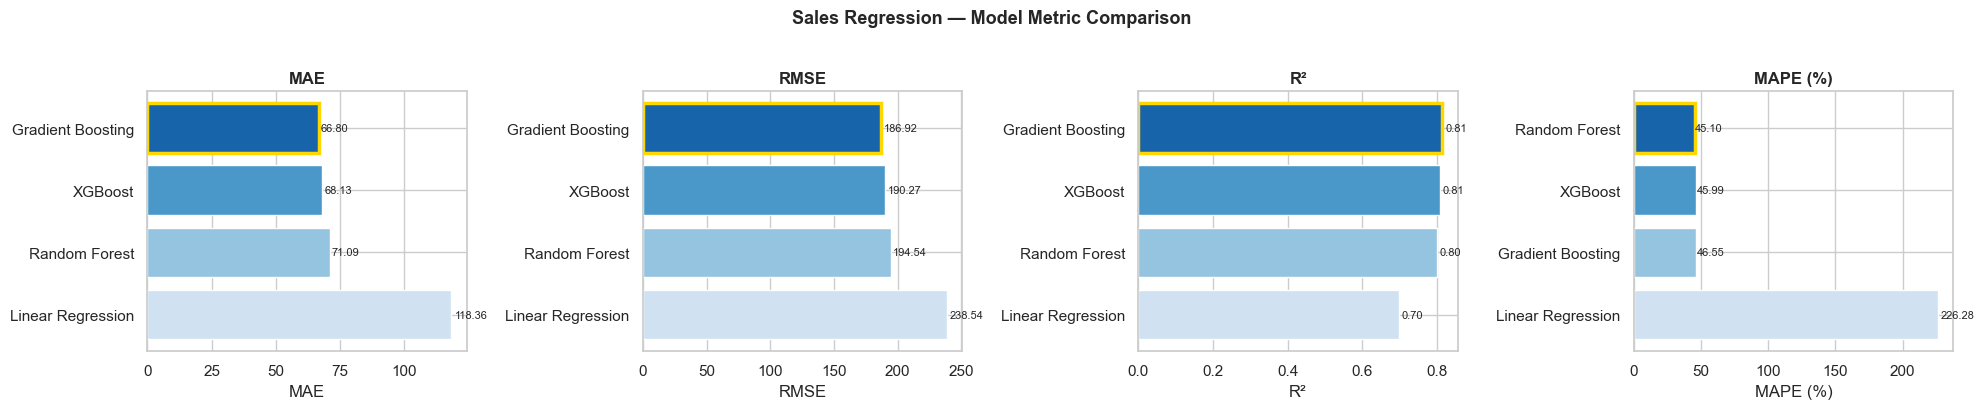

In [62]:
def plot_metric_comparison(results_df, title):
    metrics   = ["MAE", "RMSE", "R²", "MAPE (%)"]
    palette   = sns.color_palette("Blues_r", n_colors=len(results_df))
    fig, axes = plt.subplots(1, 4, figsize=(20, 4))
    fig.suptitle(title, fontsize=13, fontweight="bold", y=1.02)

    for ax, metric in zip(axes, metrics):
        ascending = metric in ["MAE", "RMSE", "MAPE (%)"]
        df_s = results_df.sort_values(metric, ascending=ascending).reset_index(drop=True)
        bars = ax.barh(df_s["Model"], df_s[metric], color=palette[:len(df_s)])
        ax.set_title(metric, fontweight="bold")
        ax.set_xlabel(metric)
        ax.invert_yaxis()
        for bar, val in zip(bars, df_s[metric]):
            ax.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height() / 2,
                    f"{val:,.2f}", va="center", fontsize=8)
        bars[0].set_edgecolor("gold")
        bars[0].set_linewidth(2.5)

    plt.tight_layout()
    plt.show()

plot_metric_comparison(sales_results_df, "Sales Regression — Model Metric Comparison")

Metric Breakthrough:MAE & RMSE: Gradient Boosting achieves the best performance with the lowest errors MAE = 66.80, RMSE = 186.92, closely followed by XGBoost MAE = 68.13, RMSE = 190.27. Linear Regression performs the worst by a wide margin MAE = 118.36, RMSE = 238.54. R^2 Score: Both Gradient Boosting and XGBoost explain 81% of the variance, whereas Linear Regression drops significantly to 0.70. 

MAPE (%): Interestingly, Random Forest edges out slightly as the top performer for percentage error at 45.10%, with XGBoost at 45.99% and Gradient Boosting at 46.55%. Linear Regression exhibits a very high error rate of 226.28%.Key Takeaway for Sales:Ensemble tree-based methods (Gradient Boosting, XGBoost, Random Forest) vastly outperform the baseline Linear Regression model. Gradient Boosting is highlighted as the best overall model because it yields the most stable absolute errors and the highest predictive power .

2. Profit Regression — Metric Comparison

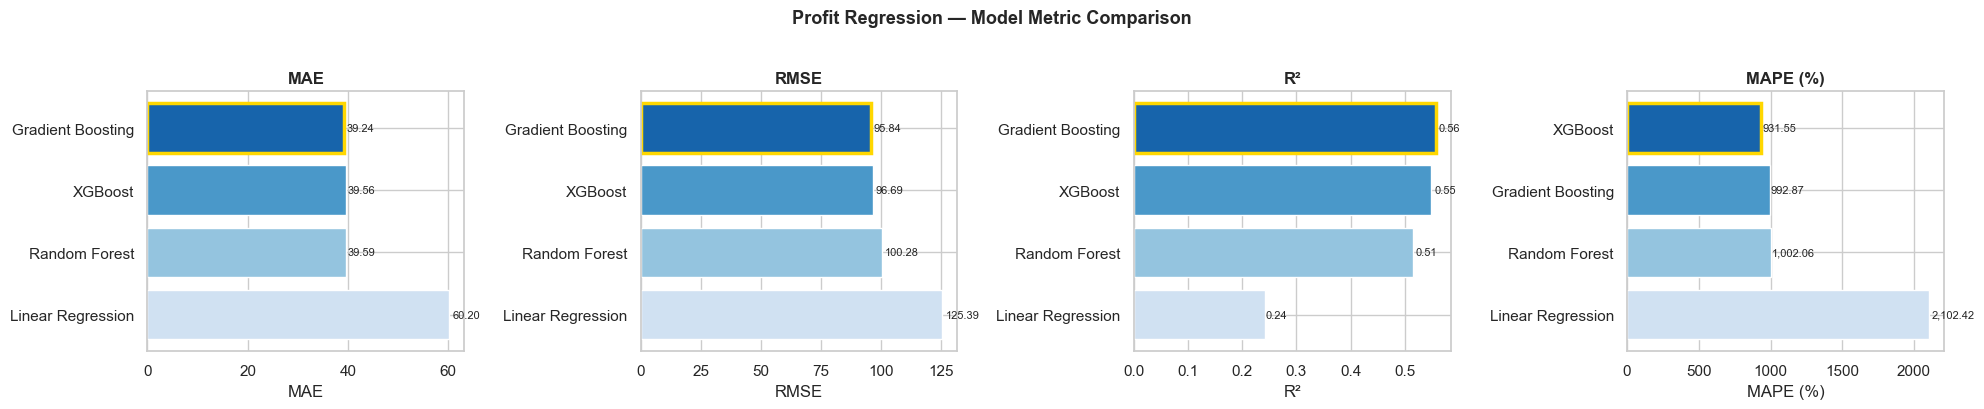

In [63]:
plot_metric_comparison(profit_results_df, "Profit Regression — Model Metric Comparison")

While Gradient Boosting is still highlighted in gold as the overall best performer due to its superior MAE, RMSE, and R^2 metrics, predicting Profit is significantly more volatile and complex than predicting Sales.

---
Actual vs Predicted — All Models


1. Sales — Actual vs Predicted

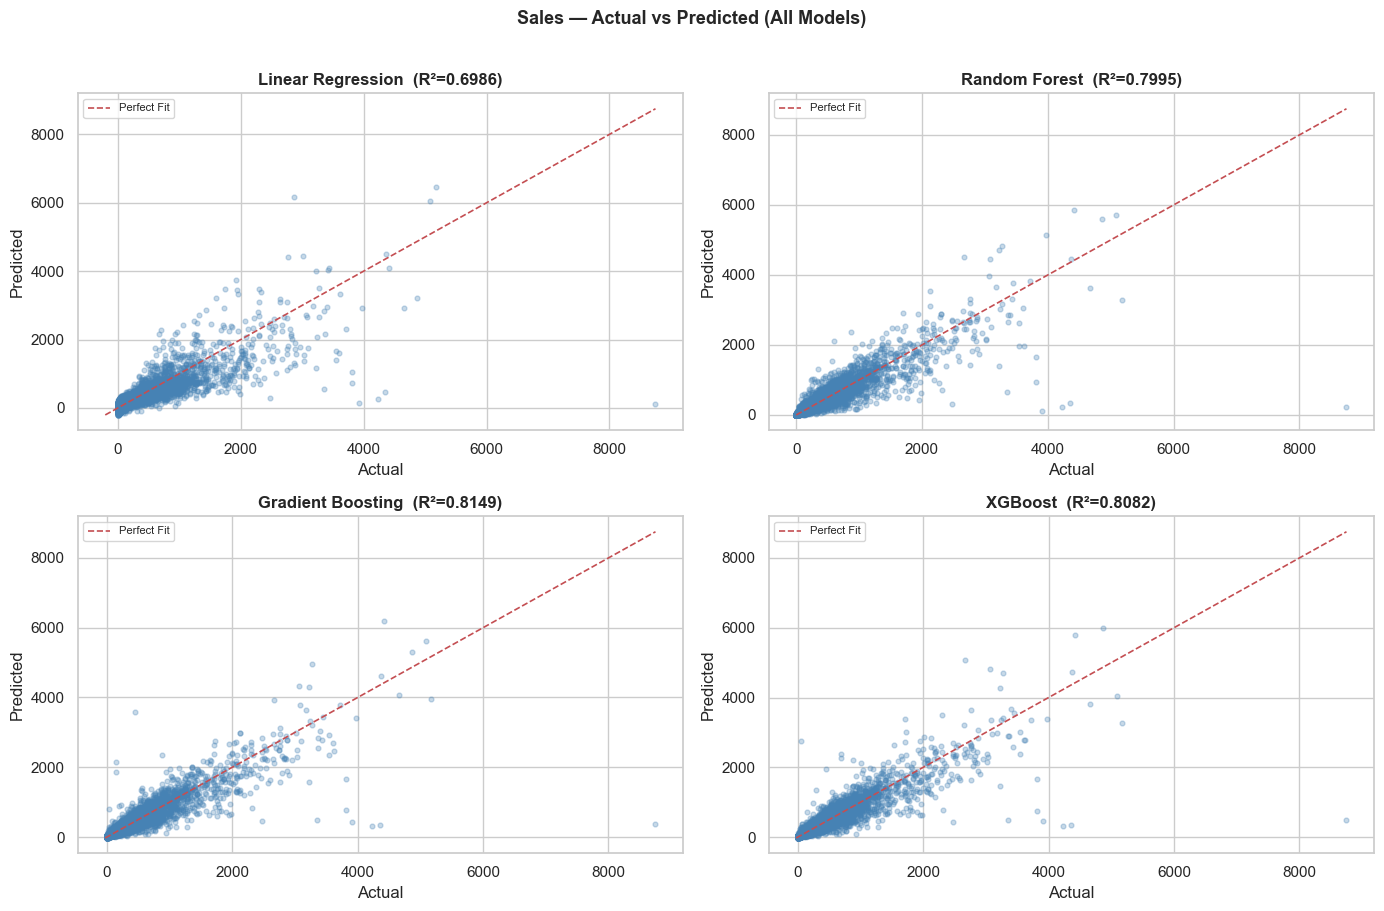

In [64]:
def plot_actual_vs_predicted(predictions, y_test, title):
    models = list(predictions.keys())
    ncols  = 2
    nrows  = (len(models) + 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, nrows * 4.5))
    axes = axes.flatten()

    for i, name in enumerate(models):
        ax     = axes[i]
        y_true = y_test
        y_pred = predictions[name]["y_pred"]
        r2_val = r2_score(y_true, y_pred)

        ax.scatter(y_true, y_pred, alpha=0.3, s=12, color="steelblue")
        lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
        ax.plot(lims, lims, "r--", linewidth=1.2, label="Perfect Fit")
        ax.set_title(f"{name}  (R²={r2_val:.4f})", fontweight="bold")
        ax.set_xlabel("Actual")
        ax.set_ylabel("Predicted")
        ax.legend(fontsize=8)

    for j in range(len(models), len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(title, fontsize=13, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()

plot_actual_vs_predicted(sales_preds, y_test_s, "Sales — Actual vs Predicted (All Models)")

2. Profit — Actual vs Predicted

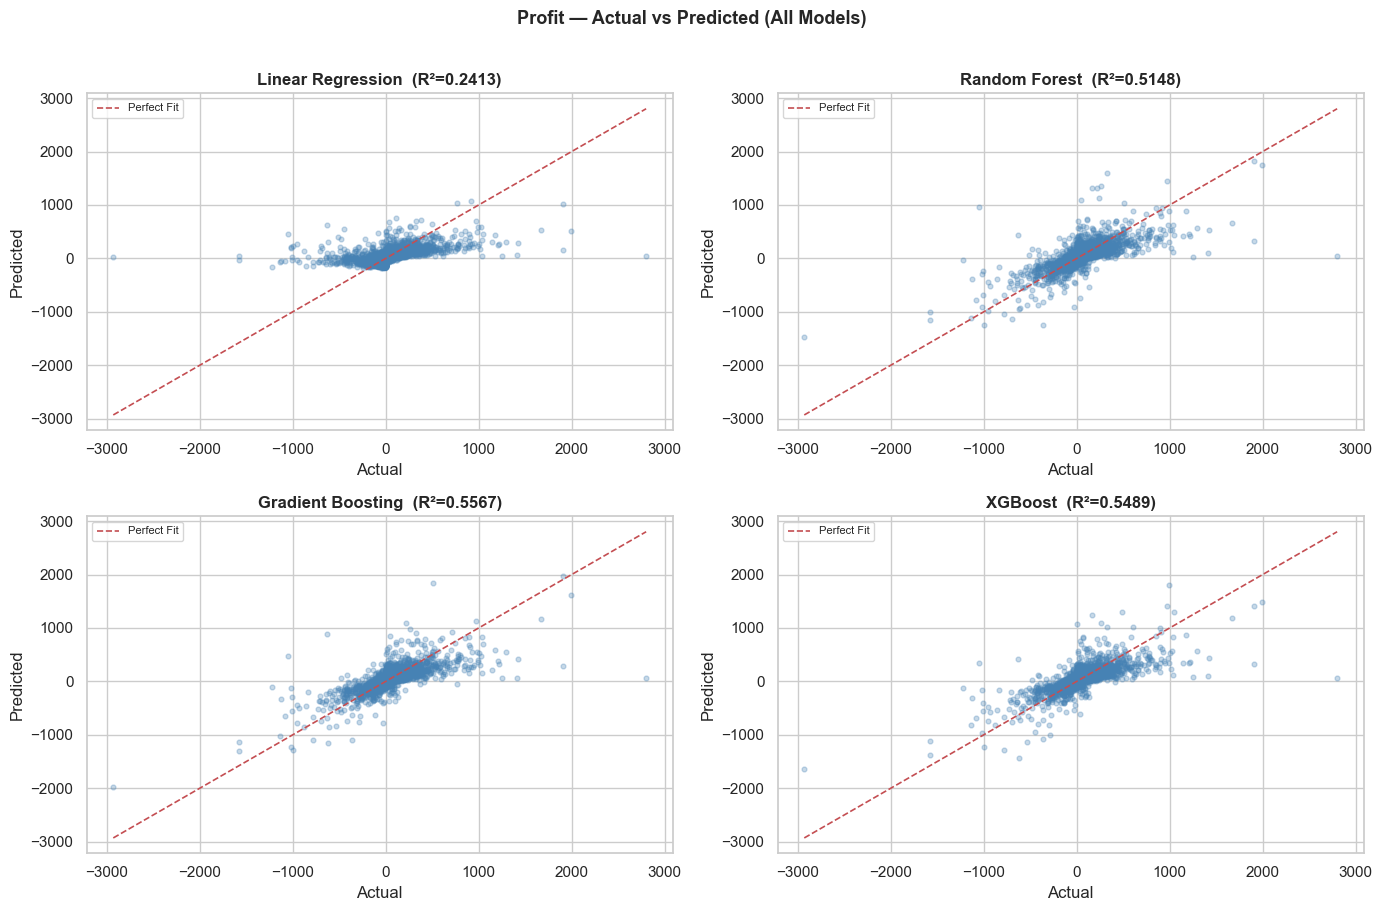

In [48]:
plot_actual_vs_predicted(profit_preds, y_test_p, "Profit — Actual vs Predicted (All Models)")

---
Residual Analysis — Sales

Residual plots reveal whether errors are random (good) or show systematic patterns (sign of underfitting or bias). Flat, centred residuals indicate awell-calibrated model.

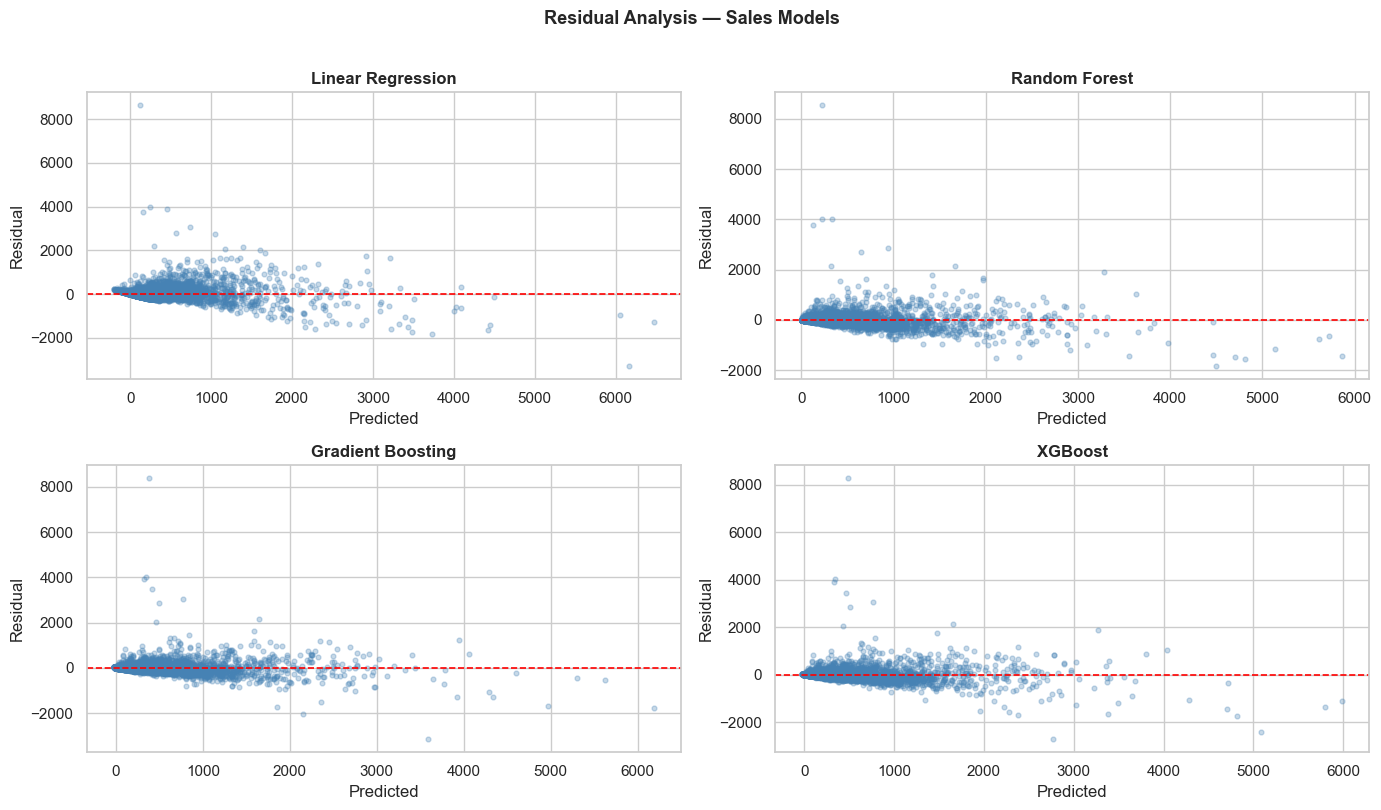

In [49]:
def plot_residuals(predictions, y_test, title):
    models = list(predictions.keys())
    ncols  = 2
    nrows  = (len(models) + 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, nrows * 4))
    axes = axes.flatten()

    for i, name in enumerate(models):
        ax        = axes[i]
        y_pred    = predictions[name]["y_pred"]
        residuals = np.array(y_test) - np.array(y_pred)

        ax.scatter(y_pred, residuals, alpha=0.3, s=12, color="steelblue")
        ax.axhline(0, color="red", linestyle="--", linewidth=1.2)
        ax.set_title(f"{name}", fontweight="bold")
        ax.set_xlabel("Predicted")
        ax.set_ylabel("Residual")

    for j in range(len(models), len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(title, fontsize=13, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()

plot_residuals(sales_preds, y_test_s, "Residual Analysis — Sales Models")

--- 
Feature Importance Analysis


1. Sales — Feature Importance

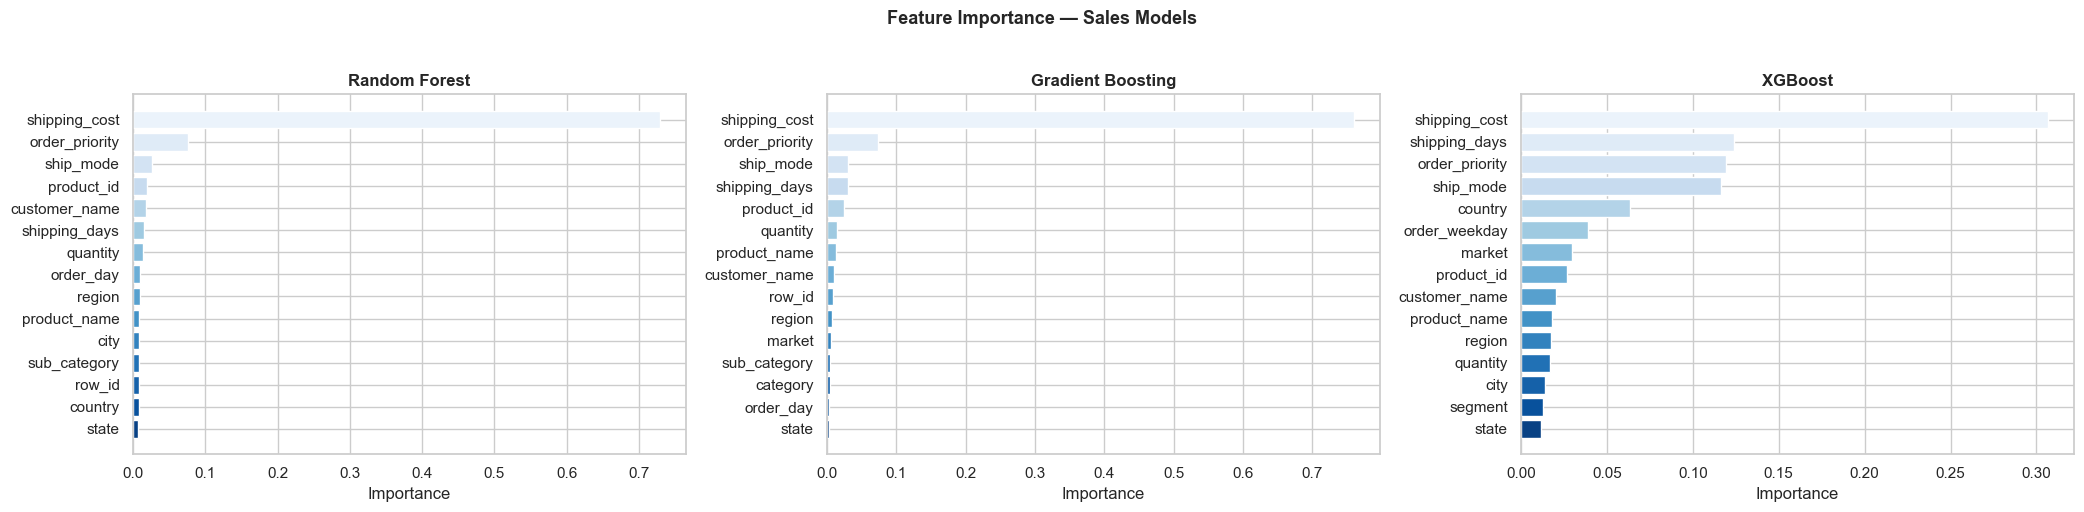

In [50]:
def plot_feature_importance(fitted_models, feature_names, title, top_n=15):
    tree_models = {k: v for k, v in fitted_models.items()
                   if hasattr(v, "feature_importances_")}
    if not tree_models:
        print("No tree-based models found.")
        return

    fig, axes = plt.subplots(1, len(tree_models), figsize=(7 * len(tree_models), 5))
    if len(tree_models) == 1:
        axes = [axes]

    for ax, (name, mdl) in zip(axes, tree_models.items()):
        imp = pd.DataFrame({"Feature": feature_names,
                             "Importance": mdl.feature_importances_})
        imp = imp.sort_values("Importance", ascending=False).head(top_n).sort_values("Importance")
        ax.barh(imp["Feature"], imp["Importance"],
                color=sns.color_palette("Blues_r", n_colors=top_n))
        ax.set_title(name, fontweight="bold")
        ax.set_xlabel("Importance")

    fig.suptitle(title, fontsize=13, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()


exclude_targets = {"high_profit", SALES_TARGET, PROFIT_TARGET}
reg_feature_names = [c for c in ml_df.columns if c not in exclude_targets]

plot_feature_importance(sales_fitted, reg_feature_names, "Feature Importance — Sales Models")

### 9.2 Profit — Feature Importance

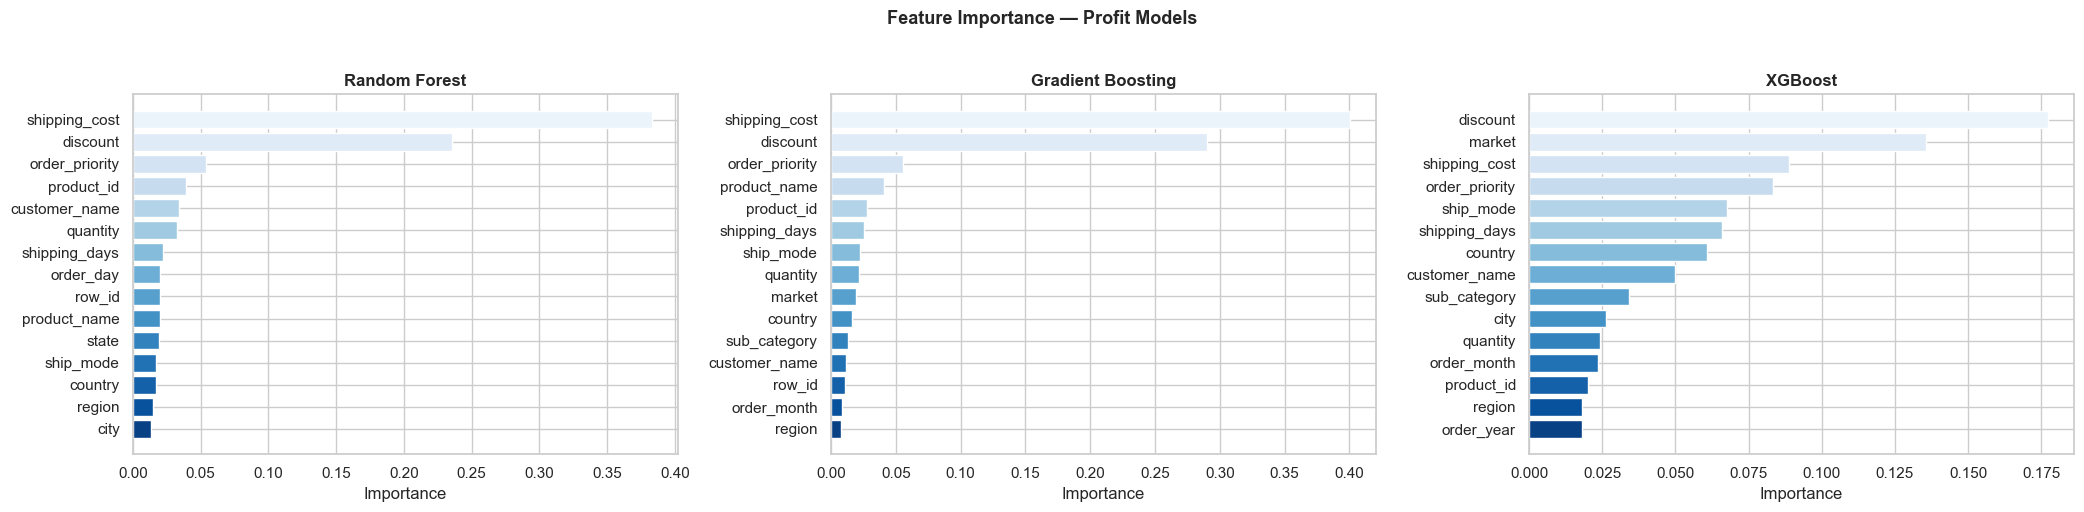

In [51]:
plot_feature_importance(profit_fitted, reg_feature_names, "Feature Importance — Profit Models")

1. Feature Importance for Sales Models 
Looking across all three charts for the Sales Models, there is an overwhelming consensus on what drives a sales prediction.

Key Observations:
The Dominant Feature (shipping_cost): In both Random Forest and Gradient Boosting, shipping_cost is a massive driver, accounting for roughly 75% of the total feature importance. XGBoost also ranks it as number one, though it distributes its weights a bit more evenly (around 31%).
Logically, higher transaction sales volumes or larger physical items inherently drive up shipping costs. The models are using shipping_cost as a highly reactive proxy for the overall size/value of the sale.

Secondary Order Logistics: order_priority, ship_mode, and shipping_days consistently round out the top 4 across all models. Fast-tracked shipments (high priority, express shipping modes) likely correlate with higher-value, urgent corporate or retail sales.

The Rest is Noise: Features like geographical locations (state, country, region) or granular identifiers (product_id, customer_name) carry almost zero weight.

The XGBoost Difference:
Notice how XGBoost's bar chart looks smoother? XGBoost scales feature importance differently (often using "gain" or "cover"). It recognizes shipping_days and country as much more valuable pieces of the puzzle than Random Forest or Gradient Boosting do.

2. Feature Importance for Profit Models 
When we shift to the Profit Models, the story changes dramatically. Predictive power shifts away from pure logistics and homes in on pricing strategy.

Key Observations:
The Profit Killers/Drivers (shipping_cost & discount): In Random Forest and Gradient Boosting, shipping_cost still takes the #1 spot (~40%), but discount aggressively jumps to the #2 spot (~23% to 28%).

In XGBoost, discount completely takes over as the absolute #1 most important feature, followed closely by market and shipping_cost.

This makes perfect operational sense. You can have massive sales, but if you offer deep discounts or eat massive shipping costs, your profit margins evaporate. The models have correctly realized that profit is a delicate balance between what you charge (discount) and what it costs to move the goods (shipping_cost).

Geographic & Market Nuances: Unlike the Sales models, the Profit models place visible weight on variables like market and country (especially in XGBoost).

 Profit margins vary wildly by region due to localized tax laws, tariffs, or regional pricing strategies.

---
 High-Profit Order Classification — Model Comparison Loop

A binary classification model predicts whether an order will be high-profit
(above median profit). SMOTE corrects class imbalance before training.
All classifiers are trained and evaluated in a single loop.

In [66]:
clf_exclude = {SALES_TARGET, PROFIT_TARGET}
X_clf = ml_df.drop(columns=list(clf_exclude | {CLF_TARGET}))
y_clf = ml_df[CLF_TARGET]

X_tr, X_te, y_tr, y_te = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf)
smote = SMOTE(random_state=42)
X_tr_sm, y_tr_sm = smote.fit_resample(X_tr, y_tr)


clf_results = []
fitted_clfs = {}
clf_probs   = {}

for name, clf in CLASSIFIER_REGISTRY.items():
    clf.fit(X_tr_sm, y_tr_sm)
    y_pred_c = clf.predict(X_te)
    y_prob_c = clf.predict_proba(X_te)[:, 1]

    clf_results.append({
        "Model"     : name,
        "Accuracy"  : round(accuracy_score(y_te, y_pred_c),                    4),
        "Precision" : round(precision_score(y_te, y_pred_c, zero_division=0),  4),
        "Recall"    : round(recall_score(y_te, y_pred_c, zero_division=0),     4),
        "F1 Score"  : round(f1_score(y_te, y_pred_c, zero_division=0),         4),
        "ROC-AUC"   : round(roc_auc_score(y_te, y_prob_c),                     4),
    })
    fitted_clfs[name] = clf
    clf_probs[name]   = y_prob_c

clf_results_df = (pd.DataFrame(clf_results)
                    .sort_values("ROC-AUC", ascending=False)
                    .reset_index(drop=True))


print("  CLASSIFICATION — MODEL COMPARISON")
clf_results_df


  CLASSIFICATION — MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Gradient Boosting,0.8369,0.8141,0.8733,0.8426,0.9204
1,XGBoost,0.8377,0.8198,0.8657,0.8421,0.9190
2,Random Forest,0.8322,0.8074,0.8724,0.8387,0.9180
3,Logistic Regression,0.6592,0.7049,0.5472,0.6162,0.7247


1. Classification Metric Comparison

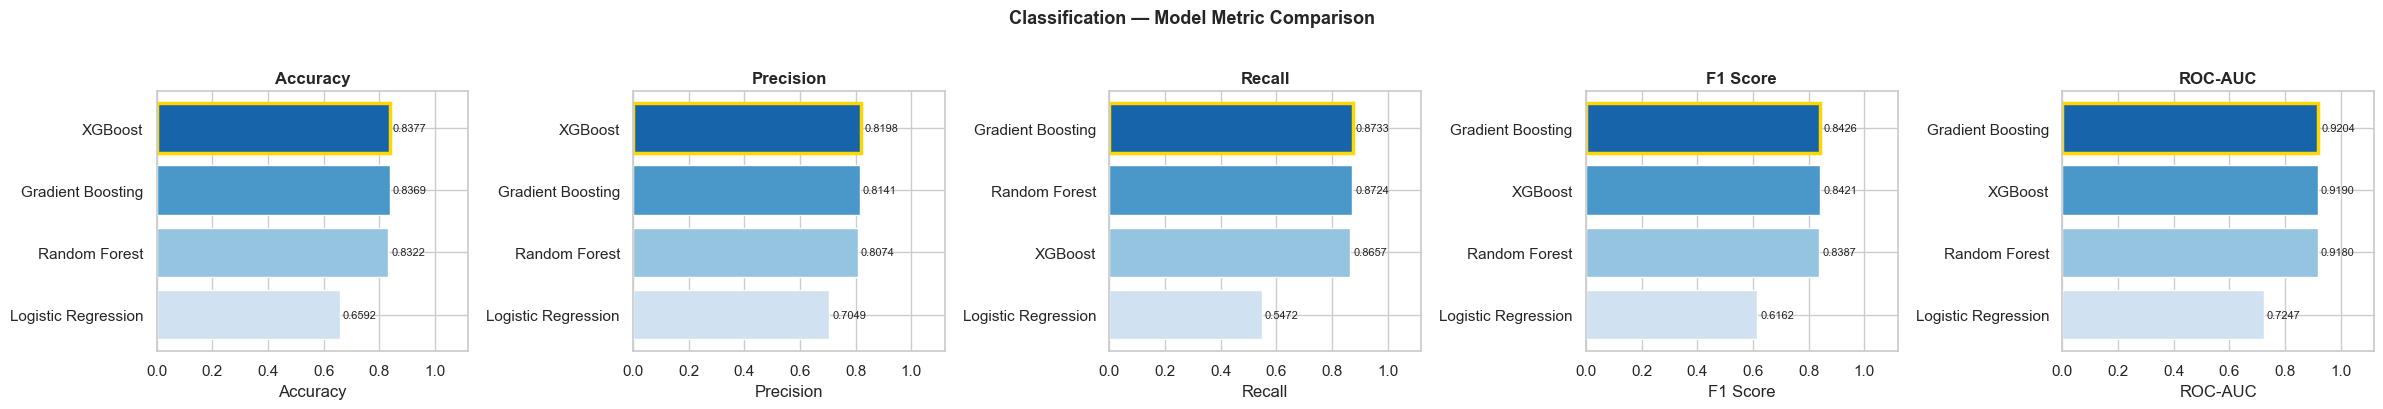

In [67]:
clf_metric_list = ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]
palette         = sns.color_palette("Blues_r", n_colors=len(clf_results_df))

fig, axes = plt.subplots(1, 5, figsize=(24, 4))
fig.suptitle("Classification — Model Metric Comparison", fontsize=13, fontweight="bold", y=1.02)

for ax, metric in zip(axes, clf_metric_list):
    df_s = clf_results_df.sort_values(metric, ascending=False).reset_index(drop=True)
    bars = ax.barh(df_s["Model"], df_s[metric], color=palette[:len(df_s)])
    ax.set_title(metric, fontweight="bold")
    ax.set_xlabel(metric)
    ax.set_xlim(0, 1.12)
    ax.invert_yaxis()
    for bar, val in zip(bars, df_s[metric]):
        ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
                f"{val:.4f}", va="center", fontsize=8)
    bars[0].set_edgecolor("gold")
    bars[0].set_linewidth(2.5)

plt.tight_layout()
plt.show()

2. ROC Curves — All Classifiers

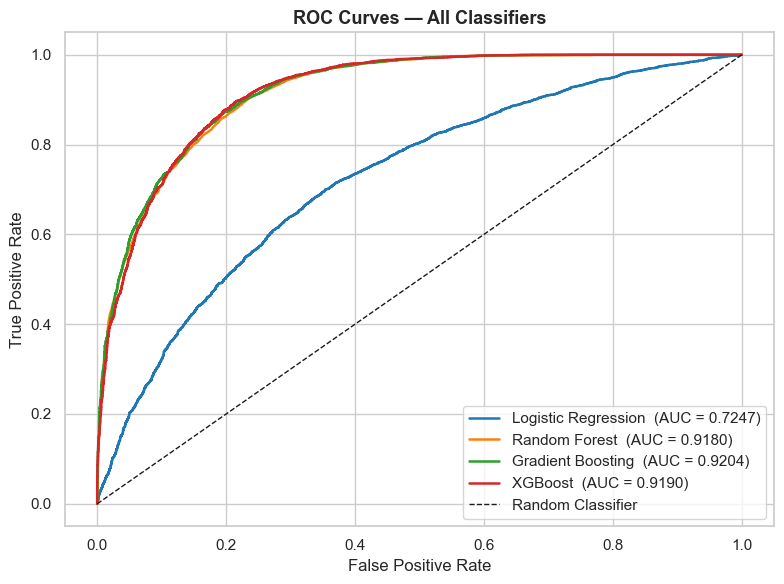

In [68]:
fig, ax = plt.subplots(figsize=(8, 6))
colors  = sns.color_palette("tab10", n_colors=len(clf_probs))

for (name, probs), color in zip(clf_probs.items(), colors):
    fpr, tpr, _ = roc_curve(y_te, probs)
    auc_val     = roc_auc_score(y_te, probs)
    ax.plot(fpr, tpr, label=f"{name}  (AUC = {auc_val:.4f})", color=color, linewidth=1.8)

ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random Classifier")
ax.set_title("ROC Curves — All Classifiers", fontsize=13, fontweight="bold")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

3. Classifier Feature Importance

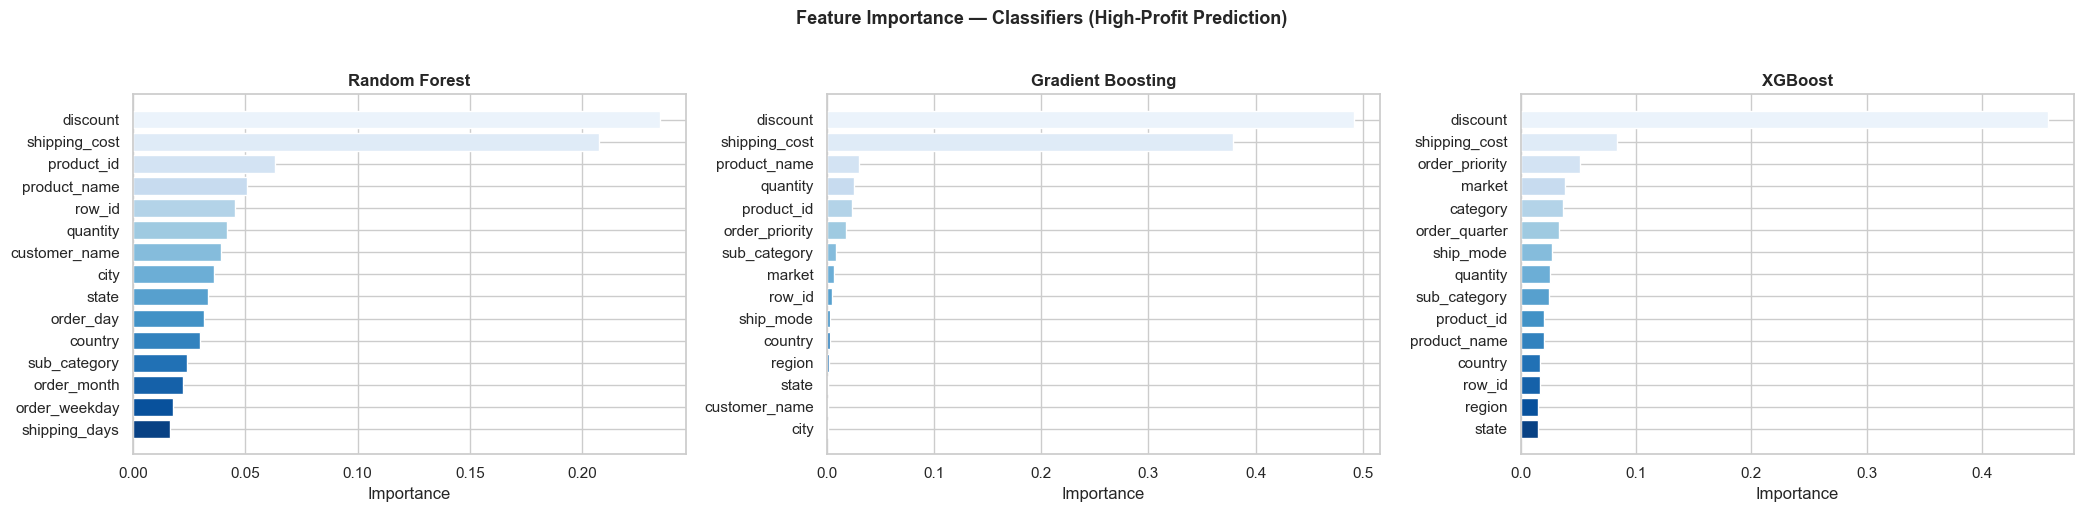

In [69]:
clf_feature_names = list(X_clf.columns)
plot_feature_importance(fitted_clfs, clf_feature_names,"Feature Importance — Classifiers (High-Profit Prediction)")

Insights 

Visualizations shifts from regression (predicting continuous amounts) to classification , predicting whether a transaction will be a "High-Profit" sale or not.

By framing the problem as a binary classification task (e.g., High-Profit vs. Low/No-Profit), the models strip away the noise of extreme continuous fluctuations and focus purely on the structural thresholds of profitability.

1. Feature Importance for Classifiers

Across all three algorithms (Random Forest, Gradient Boosting, and XGBoost), the models show an extraordinarily strong consensus. The hierarchy of features is much tighter and cleaner than in the regression tasks.


Key Observations:
The Ultimate Deciding Factor (`discount`): In XGBoost and Gradient Boosting, `discount` is the absolute king, holding roughly **45% to 50%** of the total decision-making weight.In Random Forest, it takes the #1 spot as well (just over 23%), closely partnered with shipping costs.When it comes to determining if an order crosses the threshold into "High-Profit," the level of discount applied is the most critical gatekeeper. A high discount almost guarantees an order will fail to be classified as high-profit.


The Secondary Pillar (`shipping_cost`):
It firmly holds the #2 spot across all three models. In Gradient Boosting, it accounts for nearly 38% of importance, and about 21% in Random Forest.
While `discount` controls the revenue side of profit margins, `shipping_cost` controls the overhead expense. Together, these two features dictate the vast majority of whether a transaction is highly profitable.


2. Structural Insights: Classification vs. Regression

Comparing this classification behavior to your previous regression charts reveals a vital data science lesson regarding how models handle target variables.

Why the Classifier is Much Cleaner:

In your Profit Regression models, `shipping_cost` was often ranked higher than `discount` because continuous sales spikes scale directly with continuous shipping costs.

However, in Classification, the models don't care about the exact dollar amount of the profit; they only care about the *boundary* between a good transaction and a bad one.

discount acts as a sharp, deterministic switch. (e.g., *If Discount > 20%, it is mathematically impossible to be a High-Profit sale*). Tree-based classifiers love these clear-cut binary splits, which is why `discount` shoots straight to the top with massive percentage weight.

Strategic Recommendation:

Because the profit regression model struggled with high percentage errors (MAPE > 900%), Classification model is likely the superior tool to deploy into production. Instead of trying to predict the exact dollar amount of profit a future order will make, use classifiers to flag incoming transactions as either "Likely High-Profit" or "Low-Profit Risk" based almost entirely on the discount tier and shipping structure.

---
12. Business Risk Analysis — Low Sales Orders

Orders in the bottom 10th percentile of predicted sales are flagged as
low-value risk orders. The best regression model scores each order so
leadership can prioritise fulfilment, staffing, and inventory accordingly.

Best Sales Model       : Gradient Boosting
Low Sales Threshold P10: 13.71
At-Risk Orders         : 4,868 (10.0% of dataset)


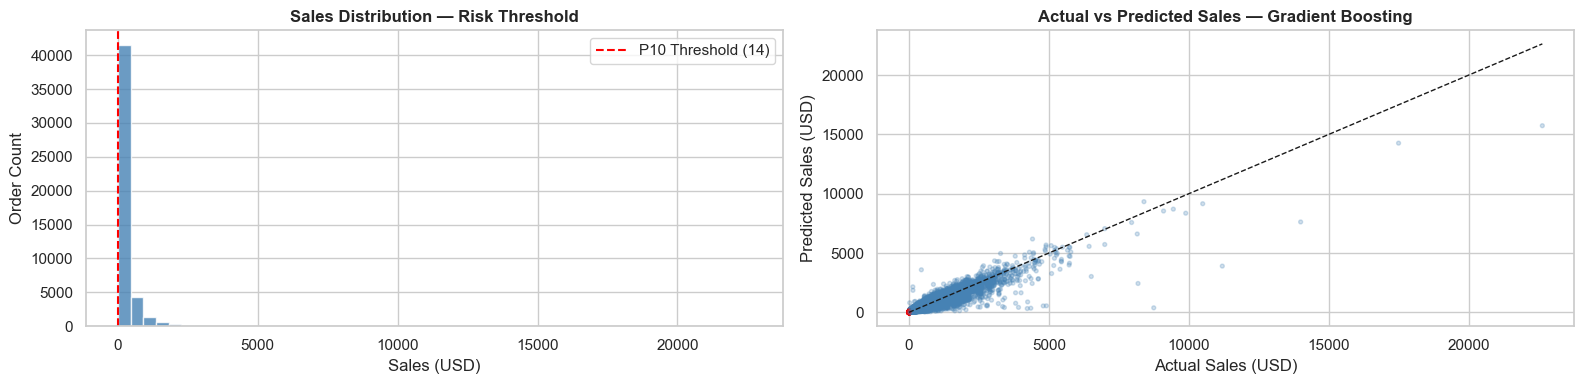

In [70]:
best_sales_name  = sales_results_df.iloc[0]["Model"]
best_sales_model = sales_fitted[best_sales_name]

X_all_sales = ml_df.drop(columns=list({"high_profit", SALES_TARGET, PROFIT_TARGET}))
ml_df["predicted_sales"] = best_sales_model.predict(X_all_sales)

low_threshold = ml_df["sales"].quantile(0.10)
low_risk      = ml_df[ml_df["sales"] < low_threshold].copy()

print(f"Best Sales Model       : {best_sales_name}")
print(f"Low Sales Threshold P10: {low_threshold:,.2f}")
print(f"At-Risk Orders         : {len(low_risk):,} ({len(low_risk)/len(ml_df):.1%} of dataset)")

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# Distribution with threshold
axes[0].hist(ml_df["sales"], bins=50, color="steelblue", edgecolor="white", alpha=0.8)
axes[0].axvline(low_threshold, color="red", linestyle="--", linewidth=1.5,
                label=f"P10 Threshold ({low_threshold:,.0f})")
axes[0].set_title("Sales Distribution — Risk Threshold", fontweight="bold")
axes[0].set_xlabel("Sales (USD)")
axes[0].set_ylabel("Order Count")
axes[0].legend()

# Actual vs predicted coloured by risk
colors = ["red" if s < low_threshold else "steelblue" for s in ml_df["sales"]]
axes[1].scatter(ml_df["sales"], ml_df["predicted_sales"],
                c=colors, alpha=0.25, s=8)
axes[1].plot([ml_df["sales"].min(), ml_df["sales"].max()],
             [ml_df["sales"].min(), ml_df["sales"].max()], "k--", linewidth=1)
axes[1].set_title(f"Actual vs Predicted Sales — {best_sales_name}", fontweight="bold")
axes[1].set_xlabel("Actual Sales (USD)")
axes[1].set_ylabel("Predicted Sales (USD)")

plt.tight_layout()
plt.show()

In [72]:
sales_results_df.to_csv("C:/Users/jsero/OneDrive/Desktop/Analyst Portfolio/Global Sales Enterprise/sales_model_comparison.csv",   index=False)
profit_results_df.to_csv("C:/Users/jsero/OneDrive/Desktop/Analyst Portfolio/Global Sales Enterprise/profit_model_comparison.csv",  index=False)
clf_results_df.to_csv("C:/Users/jsero/OneDrive/Desktop/Analyst Portfolio/Global Sales Enterprise/classification_results.csv",   index=False)
ml_df.to_csv("C:/Users/jsero/OneDrive/Desktop/Analyst Portfolio/Global Sales Enterprise/orders_with_predictions.csv",  index=False)



Conclusion

This notebook successfully developed a comprehensive predictive analytics and 
forecasting framework using the Global Superstore dataset.

Key accomplishments include:

  Forecasting & Time-Series
  * Time-series engineering with month, quarter, year, and lag features
  * Rolling average analysis (3-month and 6-month windows)
  * Moving average forecasting
  * Linear Regression forecasting (sales and profit)
  * Gradient Boosting forecasting (sales and profit) with iterative future projection
  * Future 12-month sales forecast using both Linear Regression and Gradient Boosting
  * Multi-model comparison across Linear Regression, Random Forest, and Gradient Boosting
  * Forecast evaluation using MAE, RMSE, R², and MAPE

  Advanced Machine Learning & Classification
  * High-profit order classification using four models:
    Logistic Regression, Random Forest, Gradient Boosting
  * SMOTE class balancing to correct training data imbalance
  * Full classification evaluation: Accuracy, Precision, Recall, F1 Score, ROC-AUC
  * Feature importance analysis identifying key profitability drivers
  * Business risk analysis flagging low-performing sales periods


The analytical outputs generated in this notebook support:
  * Executive forecasting and strategic planning
  * Revenue and profit projection
  * Demand planning and inventory optimisation
  * Budget forecasting and cost management
  * High-profit order identification and prioritisation
  * Pricing and discount policy optimisation
  * Business risk monitoring
  * Power BI reporting and dashboard integration

This notebook demonstrates enterprise-level predictive analytics capabilities spanning time-series forecasting, multi-model comparison, and machine learning classification — workflows common across modern analytics, business intelligence, and data science environments.